In [1]:
import time
from functools import partial

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax
from flax.training.train_state import TrainState
from tqdm import tqdm

from flightning import FLIGHTNING_PATH
from flightning.algos import get_rollouts, shac
from flightning.envs import HoveringFeaturesEnv, rollout
from flightning.modules import MLP, SHACActor, SHACCritic
from flightning.utils.math import normalize


# Train a Vision-based Policy Using SHAC

This mirrors `train_bptt_vision.ipynb` but trains the policy with
Short-Horizon Actor Critic. We keep the same pretraining stage
(supervised feature-to-state regression) to seed the actor's early
layers, then hand off to SHAC for policy optimisation.

## Define the Training Environment and Policy

In [2]:
# seed
key = jax.random.key(0)
# define the environment
drone_path = FLIGHTNING_PATH + "/objects/quadrotor_files/example_quad.yaml"
dt = 0.02

env = HoveringFeaturesEnv(
    max_steps_in_episode=3 * int(1 / 0.02),
    dt=0.02,
    delay=0.05,
    velocity_std=2.,
    yaw_scale=1.0,
    pitch_roll_scale=0.3,
    omega_std=2.,
    drone_path=drone_path,
    reward_sharpness=5.0,
    action_penalty_weight=0.5,
    num_last_quad_states=5,
    skip_frames=1,
)

# get dims
action_dim = env.action_space.shape[0]
obs_dim = env.observation_space.shape[0]
print(f"obs_dim={obs_dim}, action_dim={action_dim}")


# define actor (Gaussian policy with learnable log_std) and critic (value head)
actor_net = SHACActor(
    [obs_dim, 1024, 1024, action_dim],
    initial_scale=1.0,
    action_bias=env.hovering_action,
    initial_log_std=-2.0,
)
critic_net = SHACCritic(
    [obs_dim, 1024, 1024, 1],
    initial_scale=1.0,
)

key, key_ = jax.random.split(key)
key_actor, key_critic = jax.random.split(key_)
actor_params = actor_net.initialize(key_actor)
critic_params = critic_net.initialize(key_critic)

# idle train state used only during the data-collection pretraining stage
tx_idle = optax.adam(0)
train_state_collection = TrainState.create(
    apply_fn=actor_net.apply, params=actor_params, tx=tx_idle
)


obs_dim=86, action_dim=4


## Pretraining

### Define Policy and Rollout Function

In [3]:
def collect_data(env, policy, num_rollouts, key):
    parallel_rollout = jax.vmap(
        partial(rollout, real_step=True, num_steps=1000),
        in_axes=(None, 0, None),
    )
    rollout_keys = jax.random.split(key, num_rollouts)
    transitions = parallel_rollout(env, rollout_keys, policy)
    return transitions


def policy_collection(obs, key):
    return train_state_collection.apply_fn(train_state_collection.params, obs)

### Collect Data

In [4]:
time_rollout = time.time()
transitions = collect_data(env, policy_collection, 100, jax.random.key(3))
time_rollout = time.time() - time_rollout
print(f"Rollout time: {time_rollout}")

Rollout time: 33.15461015701294


### Create the Dataset

In [5]:
# inputs: observations
observations = transitions.obs
observations = jnp.reshape(observations, (-1, observations.shape[-1]))

# targets: quadrotor state
p = transitions.state.quadrotor_state.p
p = normalize(p, env.world_box.min, env.world_box.max)
R = transitions.state.quadrotor_state.R
v = transitions.state.quadrotor_state.v
v = normalize(v, env.v_min, env.v_max)
R = jnp.reshape(R, (*R.shape[:-2], -1))
targets = jnp.concatenate([p, R, v], axis=-1)
targets = jnp.reshape(targets, (-1, targets.shape[-1]))

### Define the Pretraining Pipeline

In [6]:
@jax.jit
def train_step(state, obs, targets):
    def loss_fn(params):
        preds = state.apply_fn(params, obs)
        loss = jnp.mean(jnp.abs(preds - targets))
        return loss

    grads = jax.grad(loss_fn)(state.params)
    new_state = state.apply_gradients(grads=grads)
    return new_state


def train_loop(state, observations, targets, epochs=100, batch_size=32):
    dataset_size = observations.shape[0]
    for epoch in tqdm(range(epochs)):
        perm = jax.random.permutation(jax.random.PRNGKey(epoch), dataset_size)
        obs_shuffled = observations[perm]
        targets_shuffled = targets[perm]

        for i in range(0, dataset_size, batch_size):
            batch_obs = obs_shuffled[i : i + batch_size]
            batch_targets = targets_shuffled[i : i + batch_size]
            state = train_step(state, batch_obs, batch_targets)

    return state

### Create Predictor MLP 

In [7]:
predictor = MLP([obs_dim, 1024, 1024, targets.shape[-1]], initial_scale=.1)
predictor_params = predictor.initialize(jax.random.PRNGKey(0))

tx_predictor = optax.adam(1e-3)
train_state_predictor = TrainState.create(
    apply_fn=predictor.apply, params=predictor_params, tx=tx_predictor
)
epochs = 500
batch_size = 1024

train_state_predictor_new = train_loop(
    train_state_predictor, observations, targets, epochs, batch_size
)

100%|██████████| 500/500 [01:17<00:00,  6.49it/s]


### Copy Parameters to Actor

In [8]:
# Copy the pretrained predictor's first two dense layers into the actor.
# SHACActor uses @compact, so its Dense layers are auto-named Dense_0,
# Dense_1, ... matching the predictor's naming.
actor_params['params']['Dense_0'] = train_state_predictor_new.params['params']['Dense_0']
actor_params['params']['Dense_1'] = train_state_predictor_new.params['params']['Dense_1']


## Create Policy Optimization Environment

In [9]:
env = HoveringFeaturesEnv(
    max_steps_in_episode=3 * int(1 / dt),
    dt=dt,
    delay=0.05,
    velocity_std=0.1,
    yaw_scale=1.0,
    pitch_roll_scale=0.1,
    omega_std=0.1,
    drone_path=drone_path,
    reward_sharpness=5.0,
    action_penalty_weight=0.5,
    num_last_quad_states=5,
    skip_frames=1,
)

# build SHAC train states (actor + critic)
actor_tx = optax.adam(optax.cosine_decay_schedule(1e-3, 1000))
critic_tx = optax.adam(1e-3)
actor_state = TrainState.create(
    apply_fn=actor_net.apply, params=actor_params, tx=actor_tx
)
critic_state = TrainState.create(
    apply_fn=critic_net.apply, params=critic_params, tx=critic_tx
)

## Train the Policy Using SHAC

In [10]:
time_start = time.time()
res_dict = shac.train(
    env,
    actor_state,
    critic_state,
    num_epochs=500,
    num_steps_per_epoch=env.max_steps_in_episode,
    num_envs=1000,
    key=jax.random.key(0),
    config=shac.Config(
        gamma=0.99,
        lam=0.95,
        critic_iterations=8,
        num_batches=4,
    ),
)
time_train = time.time() - time_start
print(f"Training time: {time_train}")

[shac] epoch 0: actor_loss=0.101
[shac] epoch 10: actor_loss=0.118
[shac] epoch 20: actor_loss=0.103
[shac] epoch 30: actor_loss=0.091
[shac] epoch 40: actor_loss=0.074
[shac] epoch 50: actor_loss=0.071
[shac] epoch 60: actor_loss=0.066
[shac] epoch 70: actor_loss=0.059
[shac] epoch 80: actor_loss=0.058
[shac] epoch 90: actor_loss=0.057
[shac] epoch 100: actor_loss=0.056
[shac] epoch 110: actor_loss=0.055
[shac] epoch 120: actor_loss=0.055
[shac] epoch 130: actor_loss=0.054
[shac] epoch 140: actor_loss=0.053
[shac] epoch 150: actor_loss=0.052
[shac] epoch 160: actor_loss=0.052
[shac] epoch 170: actor_loss=0.051
[shac] epoch 180: actor_loss=0.050
[shac] epoch 190: actor_loss=0.051
[shac] epoch 200: actor_loss=0.051
[shac] epoch 210: actor_loss=0.050
[shac] epoch 220: actor_loss=0.050
[shac] epoch 230: actor_loss=0.050
[shac] epoch 240: actor_loss=0.050
[shac] epoch 250: actor_loss=0.050
[shac] epoch 260: actor_loss=0.050
[shac] epoch 270: actor_loss=0.049
[shac] epoch 280: actor_loss=0.

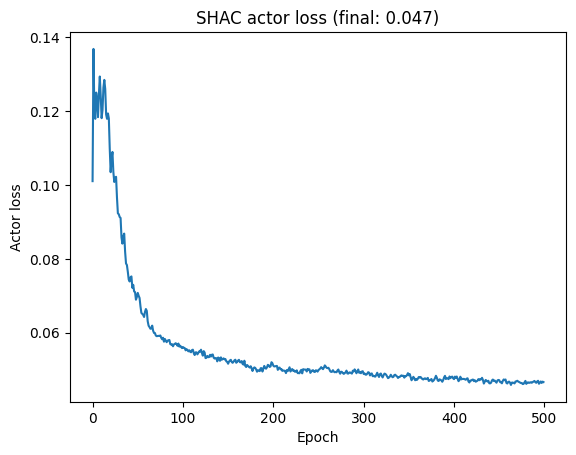

In [11]:
actor_losses = jnp.asarray(res_dict["metrics"]["actor_loss"])
plt.plot(actor_losses)
plt.title(f"SHAC actor loss (final: {actor_losses[-1]:.3f})")
plt.xlabel("Epoch")
plt.ylabel("Actor loss")
plt.show()

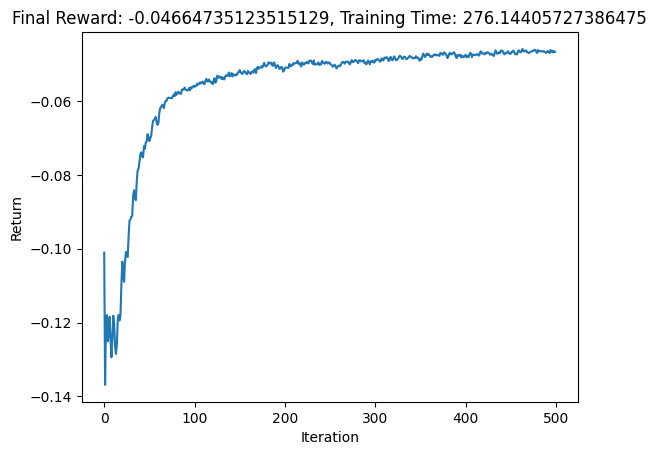

In [12]:
rewards = -jnp.asarray(res_dict["metrics"]["actor_loss"])
plt.plot(rewards)
plt.title(f"Final Reward: {rewards[-1]}, Training Time: {time_train}")
plt.xlabel("Iteration")
plt.ylabel("Return")
plt.show()

## Evaluate the Trained Policy

In [13]:
new_actor_state = res_dict["runner_state"].actor_state


def policy_trained(obs, key):
    sample = new_actor_state.apply_fn(
        new_actor_state.params, obs, key, True, method="sample_action"
    )
    return sample.action


In [14]:
env_eval = HoveringFeaturesEnv(
    max_steps_in_episode=10 * int(1 / dt),
    dt=dt,
    delay=0.05,
    velocity_std=0.1,
    yaw_scale=1.0,
    pitch_roll_scale=0.1,
    omega_std=0.1,
    drone_path=drone_path,
    num_last_quad_states=5,
    skip_frames=1,
)
transitions_eval = get_rollouts(env_eval, policy_trained, 20, jax.random.key(3))


/home/tong/tongworkspace/paperworkspace/rpg_flightning/flightning/envs/hovering_state_env.py:376: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


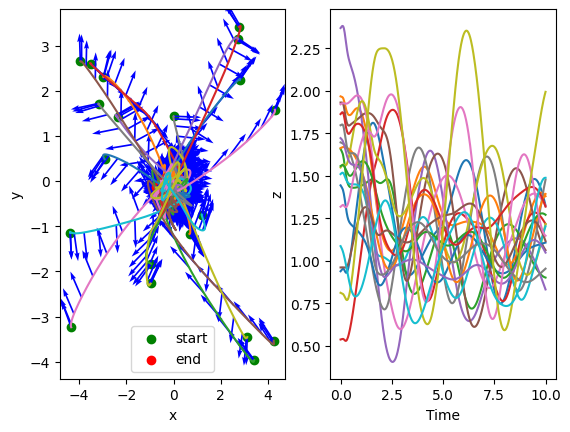

In [15]:
env_eval.plot_trajectories(transitions_eval)

In [16]:
def summarize_eval_metrics(transitions, env_eval, *, time_train, num_training_envs):
    rewards = transitions.reward[1:]
    positions = transitions.state.quadrotor_state.p[1:]
    position_errors = positions - env_eval.goal
    position_sq_error = jnp.sum(position_errors ** 2, axis=-1)
    episode_returns = jnp.sum(rewards, axis=0)
    collided = jnp.any(transitions.terminated[1:], axis=0)
    num_training_steps = (
        res_dict["metrics"]["actor_loss"].shape[0]
        * env.max_steps_in_episode
        * num_training_envs
    )
    metrics = {
        "mean_return": jnp.mean(episode_returns),
        "return_std": jnp.std(episode_returns),
        "position_mse": jnp.mean(position_sq_error),
        "final_position_mse": jnp.mean(position_sq_error[-1]),
        "final_position_rmse": jnp.sqrt(jnp.mean(position_sq_error[-1])),
        "collision_rate": jnp.mean(collided.astype(jnp.float32)),
        "num_training_steps": num_training_steps,
        "steps_per_second": num_training_steps / time_train,
        "return_per_second": jnp.mean(episode_returns) / time_train,
    }
    for name, value in metrics.items():
        print(f"{name}: {float(value):.6g}")
    return metrics


eval_metrics = summarize_eval_metrics(
    transitions_eval,
    env_eval,
    time_train=time_train,
    num_training_envs=1000,
)


mean_return: -0.313277
return_std: 0.452673
position_mse: 1.74978
final_position_mse: 0.585435
final_position_rmse: 0.765137
collision_rate: 0
num_training_steps: 7.5e+07
steps_per_second: 271597
return_per_second: -0.00113447
